In [2]:
import pandas as pd
import scipy


# Read a single CSV.GZ file
df = pd.read_csv('../data/csv/2024-08-28/2024-08-28.blocks.csv.gz', compression='gzip')

print(f"Data shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head()

Data shape: (30680, 2)
Columns: ['did', 'subj']


,did,subj
0,ewh2u4eytyerjlef2sxd6dxe,evysrvt56n2caghe5w5tidwq
1,z2jiqyfmu4xnxzrxorqsw3xg,ilqazgl7rlh64xwwwcrfpoqi
2,vuuehkuq7yaya2ce4j5mdwxe,3mhduhawjwcst5uugzj2o6j5
3,6orrijlm26ssnwvfwsvmydsl,z3uh6dme22hydm4loftjktaj
4,gdbsa77nmz6pqdb7th3k5rwh,inbwlekwvfnyphf5cma6hxds


In [4]:
# Read a single CSV.GZ file
df = pd.read_csv('../data/csv/2024-08-28/2024-08-28.blocks_extended.csv.gz', compression='gzip')

print(f"Data shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head()

Data shape: (44808, 4)
Columns: ['did', 'subj', 'uri', 'time']


,did,subj,uri,time
0,ck4ma6dnnemtkoe2tduiqonc,sgks6xnzealdmfxyhdmywhvr,3l2qg74puuv2r,1724796002
1,q45im4j5dtstg4tgffb64k7b,3b5c2ng23jaclh5632qiwgaz,3l2qg7gc2lm2c,1724796012
2,ck4ma6dnnemtkoe2tduiqonc,o2dz5dqkt64fdbvnutc4472w,3l2qg7ie5662j,1724796014
3,pkmsjqgmircj3d6bwguubmsd,gw4yf44wu2h6c67l6fwrpqct,3l2qg7jclgf2e,1724796015
4,nsqm4svv5k66mwzokfrmsivj,fz4idu4opme7ybgcwso7cib6,3l2qg7npwsx2z,1724796020


In [5]:
df = pd.read_csv('../data/csv/2024-08-28/2024-08-28.likes.csv.gz', compression='gzip')

print(f"Data shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head()

Data shape: (2126138, 3)
Columns: ['did', 'subj', 'c']


,did,subj,c
0,soofgffsi2ak7imvpty64qkp,wdrdm5zsrad2abdfmobhl36f,3
1,dhwilxubgan7krkvkjvibjtf,rhtvsz7ojtzpov6icmji7bek,1
2,luldl5dtyrrdnlazf4njcelc,4y25v6oe2mpxzqpbj5wf7qi4,1
3,46f2wggwueimfxr5j56jrqg6,vuuehkuq7yaya2ce4j5mdwxe,3
4,n7n6vtfy4qrr6flqwzzgki66,mmzzps7ujtzias5cph45wkd6,27


In [12]:
follows_df = pd.read_csv('../data/csv/2024-08-28/2024-08-28.follows.csv.gz', compression='gzip')

print(f"Data shape: {follows_df.shape}")
print(f"Columns: {follows_df.columns.tolist()}")
follows_df.head()

Data shape: (310012, 2)
Columns: ['did', 'subj']


,did,subj
0,vnrqgvtuvetekkst2vqfki4n,hakzua5btcgcfjye2yujlhos
1,2yw5xnggljibtjcvpgdclz4q,euyajapadn6ca6kg64ihclyv
2,tv2evowiy4evqxojgtsmc52k,dizl5cy6ze7g3uhzflo536dw
3,o3g3qfu37nds2lmdb6gx73yt,ky4whfawmghac3xp3qxwelou
4,fsfj3eye7qs45ld7wf6pstmr,7hbjqmaymw5fuvkixaprmm3r


In [7]:
df = pd.read_csv('../data/csv/2024-08-28/2024-08-28.actions.csv.gz', compression='gzip')

print(f"Data shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head()

Data shape: (577510, 4)
Columns: ['did', 'type', 'action', 'c']


,did,type,action,c
0,5flpylkt3iwrnow2krke5mcw,app.bsky.graph.follow,create,7
1,rmtxia3nqboynasfchuqlqx2,app.bsky.actor.profile,update,2
2,soofgffsi2ak7imvpty64qkp,app.bsky.feed.like,create,20
3,dhwilxubgan7krkvkjvibjtf,app.bsky.feed.like,create,15
4,y3z5svi72siyqy3meapbqy4b,app.bsky.graph.follow,create,9


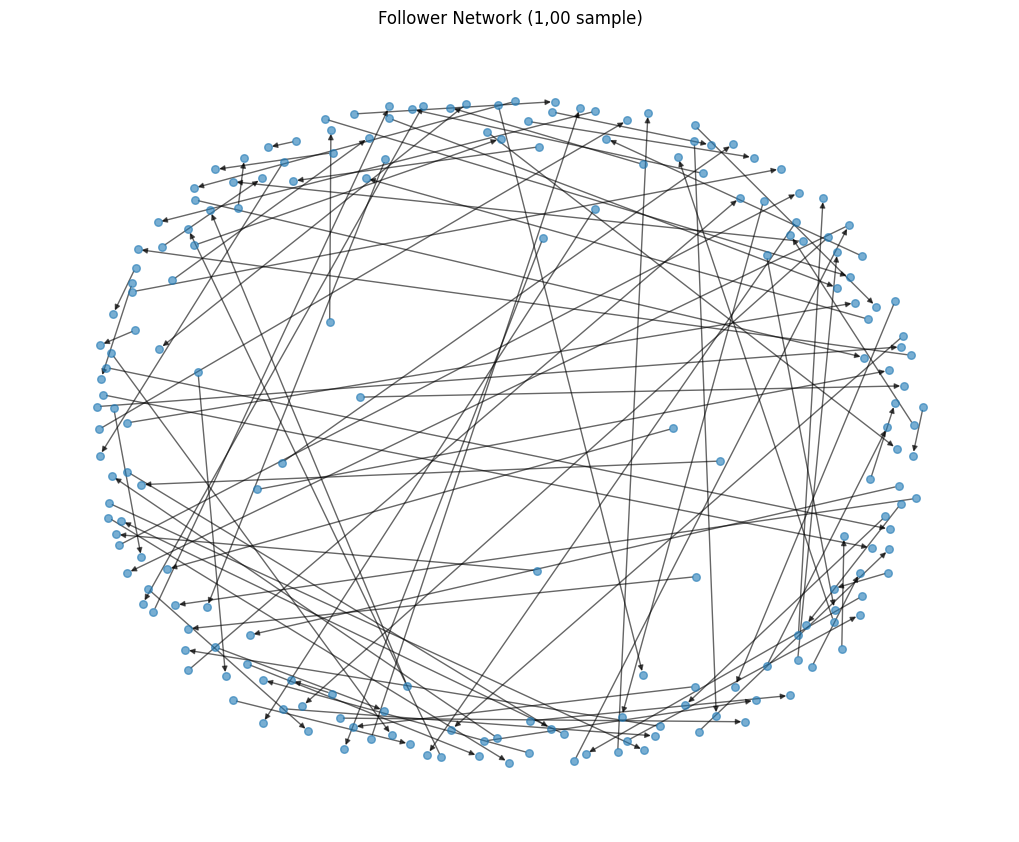

In [22]:
import networkx as nx
import matplotlib.pyplot as plt

# Take a random sample for visualization
sample_follows = follows_df.sample(n=100, random_state=42)  # 1000 relationships

G = nx.DiGraph()
for _, row in sample_follows.iterrows():
    G.add_edge(row['did'][:10] + '...',  # Truncate for readability
               row['subj'][:10] + '...')

plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G, k=1, iterations=50)  # Fewer iterations
nx.draw(G, pos, node_size=30, alpha=0.6, arrows=True, arrowsize=8, font_size=8)
plt.title("Follower Network (1,00 sample)")
plt.show()